[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rycroft-group/math513/blob/main/6_iter/6_iter.ipynb)

In [1]:
# Necessity libraries
import numpy as np
import matplotlib.pyplot as plt

# Optional: a library for plotting with LaTeX-like
# styles nicer formatted figures
# Warning: need to have LaTeX installed
import scienceplots
plt.style.use(['science'])

In [2]:
import os
os.makedirs("results", exist_ok=True)

# Unit 6: Iterative methods

## Lecture 34: More on Arnoldi iteration

### Code demo 1: Use Arnoldi iteration to approximate eigenvalues of a matrix

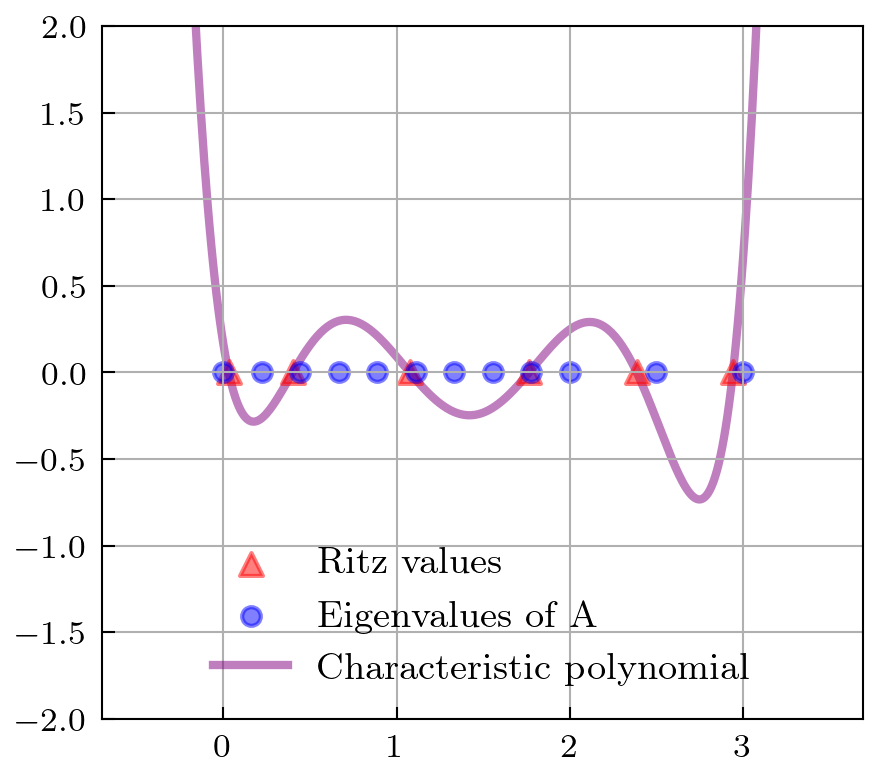

Ritz values:
[2.94151226 2.38631592 1.7654115  0.03111306 0.4004782  1.07582453]


In [3]:
# Define the vector A
w = 10
diag_vector = np.concatenate([np.linspace(0, 2, w), [2.5, 3.0]])
A = np.diag(diag_vector)
m = w + 2

# Initialize Q, alpha, and beta
n_max = 6
Q = np.zeros((m, n_max))

# Define a random initial vector
b = np.random.randn(m)
Q[:, 0] = b / np.linalg.norm(b)

# The Arnoldi iteration loop
for n in range(n_max - 1):
    v = A @ Q[:, n]
    for l in range(n + 1):
        s = np.dot(Q[:, l].conj(), v)
        v = v - s * Q[:, l]
    b = np.linalg.norm(v)
    Q[:, n + 1] = v / b

H_n = Q.T @ A @ Q
V = np.linalg.eigvals(H_n)

fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)
# Plot the roots
ax.scatter(V, np.zeros_like(V), s=30, marker='^', color='r', label='Ritz values', alpha=0.5)
ax.scatter(diag_vector, np.zeros_like(diag_vector), s=20, color='blue', label='Eigenvalues of A', alpha=0.5)
# Plot the characteristic polynomial
p = np.poly(H_n)
xrange = np.arange(-0.5, 3.5, 0.01)
ax.plot(xrange, np.polyval(p, xrange), color='purple', linewidth=2, label='Characteristic polynomial', zorder=0, alpha=0.5)

# Formatting
ax.set_ylim(-2, 2)
ax.legend(loc='lower center', fontsize=9)
# Prettify
ax.grid(True, linewidth=0.5)
ax.set_aspect('equal')
# ax.set_xlim(-0.5, 3.5)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)

# Save the figure
# plt.savefig("results/arnoldi.pdf", bbox_inches='tight', dpi=300)
plt.show()

# Print out the Ritz values
print("Ritz values:")
print(V)

## Lecture 35: Lanczos iteration

### Code demo 1: Find eigenvalues of a symmetric matrix

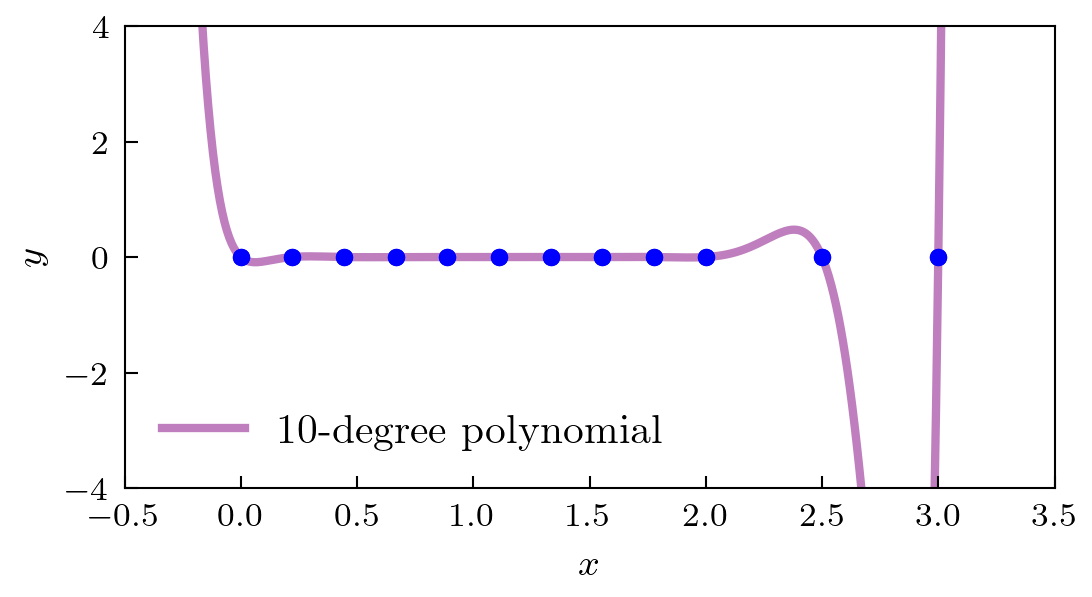

In [4]:
# Define the vector A
n = 10
diag_vector = np.concatenate((np.linspace(0., 2., n), np.array([2.5, 3.])))
A = np.diag(diag_vector)

# Initialize Q, alpha and beta
iters = 11
Q = np.zeros((n+2, iters+1))
alpha = np.zeros((iters))
beta = np.zeros((iters))

# Define a random initial vector
b = np.random.randn(n+2)
Q[:, 0] = b/np.linalg.norm(b)

# The Lanczos iteration loop
for m in range(iters):
    v = np.dot(A, Q[:, m])
    alpha[m] = np.dot(Q[:, m], v)
    if m == 0:
        v = v-alpha[m]*Q[:, m]
    else:
        v = v-beta[m-1]*Q[:, m-1]-alpha[m]*Q[:, m]
    beta[m] = np.linalg.norm(v)
    Q[:, m+1] = v/beta[m]

H_m = np.dot(np.dot(Q.T, A), Q)
[V, D] = np.linalg.eig(H_m)

# Store the characteristic polynomial
results_cp = []
p = np.poly(H_m)
x = -0.5
while x <= 3.5:
    results_cp.append((x, np.polyval(p, x)))
    x += 0.01

# Store the roots
results_roots = []
for i in range(n+2):
    results_roots.append((diag_vector[i], 0))
for i in range(iters+1):
    results_roots.append((V[i], 0))

# Visualize
x_plot, y_plot = zip(*results_cp)
roots = np.array(results_roots)
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=300)
ax.scatter(roots[:, 0], roots[:, 1], s=10, color='blue')
ax.plot(x_plot, y_plot, color='purple', linewidth=2,zorder=0, alpha=0.5, label=str(n)+'-degree polynomial')
# Formatting
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$y$', fontsize=9)
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-4, 4)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
ax.legend()

# Save the figure
# plt.savefig("results/lanczos.pdf", bbox_inches='tight', dpi=300)
plt.show()